In [1]:
import pyarrow.parquet as pq
import polars as pl
pl.Config.set_tbl_cols(20)          # Show up to 20 columns
pl.Config.set_tbl_rows(30)          # Show up to 20 columns
pl.Config.set_tbl_width_chars(200)  # Make the table wider in the console
pl.Config.set_fmt_str_lengths(50)   # Don't cut off long strings like stoch_key

results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260327_132733_01\master_metrics.parquet'

# Open the file metadata
parquet_file = pq.ParquetFile(results_path)

# 1. Get Row Count
print(f"Total Rows: {parquet_file.metadata.num_rows}")

# 2. Get Schema
print("Schema:")
print(parquet_file.schema)

Total Rows: 1101072
Schema:
required group field_id=-1 schema {
  optional int32 field_id=-1 regime_id;
  optional int64 field_id=-1 era_int;
  optional int32 field_id=-1 side (Int(bitWidth=8, isSigned=true));
  optional int32 field_id=-1 ma_int;
  optional boolean field_id=-1 ma_reversion;
  optional int32 field_id=-1 entry_lookback_units;
  optional int32 field_id=-1 exit_window_h;
  optional boolean field_id=-1 use_stochastic;
  optional binary field_id=-1 stoch_key (String);
  optional boolean field_id=-1 use_bbw;
  optional int32 field_id=-1 bbw_periods;
  optional float field_id=-1 bbw_std;
  optional int32 field_id=-1 bbw_thresholds;
  optional float field_id=-1 SL;
  optional float field_id=-1 TP;
  optional boolean field_id=-1 use_sl_decay;
  optional float field_id=-1 sl_decay_pct;
  optional int32 field_id=-1 sl_decay_interval;
  optional boolean field_id=-1 sl_decay_stop_at_pos;
  optional int32 field_id=-1 total_pos;
  optional int32 field_id=-1 win_pos;
  optional float f

In [66]:
import polars as pl

# 1. Define the Path
results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260324_114114_01\master_metrics.parquet'

# 2. Define the Target Criteria
TARGET_TP = 2.0
TARGET_SLS = [0.1, 0.2]
TARGET_STOCH = "k6_d6_s6_l30_u70"
TARGET_MAs = 7
TARGET_LOOKBACKS = 6, 8

# 3. Load and Filter
df = pl.read_parquet(results_path)

# Filter for the "Workhorse" configs (with and without BBW 96)
df_regimes = df.filter(
    (pl.col("TP") == TARGET_TP) &
    (pl.col("SL").is_in(TARGET_SLS)) &
    (pl.col("stoch_key") == TARGET_STOCH) &
    (pl.col("ma_int").is_in(TARGET_MAs)) &
    (pl.col("entry_lookback_units").is_in(TARGET_LOOKBACKS)) &
    (
        (pl.col("use_bbw") == False) | 
        ((pl.col("use_bbw") == True) & (pl.col("bbw_periods") == 96))
    )
)

# 4. Extract Unique Regime IDs and their associated parameters
regime_map = (
    df_regimes.select([
        "regime_id", "ma_int", "entry_lookback_units", "SL", "use_bbw", "bbw_periods"
    ])
    .unique()
    .sort("regime_id")
)

print("--- TARGET REGIME IDs FOR PRODUCTION ---")
print(regime_map)

# 5. Export for your Telegram Dash / Trading Bot
# regime_map.write_csv("production_regime_ids.csv")

--- TARGET REGIME IDs FOR PRODUCTION ---
shape: (32, 6)
┌───────────┬────────┬──────────────────────┬─────┬─────────┬─────────────┐
│ regime_id ┆ ma_int ┆ entry_lookback_units ┆ SL  ┆ use_bbw ┆ bbw_periods │
│ ---       ┆ ---    ┆ ---                  ┆ --- ┆ ---     ┆ ---         │
│ i32       ┆ i32    ┆ i32                  ┆ f32 ┆ bool    ┆ i32         │
╞═══════════╪════════╪══════════════════════╪═════╪═════════╪═════════════╡
│ 2016      ┆ 7      ┆ 6                    ┆ 0.1 ┆ false   ┆ 0           │
│ 2016      ┆ 7      ┆ 6                    ┆ 0.2 ┆ false   ┆ 0           │
│ 2017      ┆ 7      ┆ 6                    ┆ 0.1 ┆ false   ┆ 0           │
│ 2017      ┆ 7      ┆ 6                    ┆ 0.2 ┆ false   ┆ 0           │
│ 2018      ┆ 7      ┆ 6                    ┆ 0.1 ┆ false   ┆ 0           │
│ 2018      ┆ 7      ┆ 6                    ┆ 0.2 ┆ false   ┆ 0           │
│ 2019      ┆ 7      ┆ 6                    ┆ 0.1 ┆ false   ┆ 0           │
│ 2019      ┆ 7      ┆ 6        

In [ ]:
import polars as pl

# ================================
# CONFIG
# ================================
MIN_TRADES_PER_CONFIG = 15
EPS = 1e-9

# ================================
# LOAD
# ================================
df = pl.read_parquet(results_path)

# ================================
# CLEAN + BASE FILTER
# ================================
df = (
    df
    .filter(pl.col("stoch_key").is_not_null())
    .filter(pl.col("stoch_key") != "OFF")
    .filter(pl.col("total_pos") > 0)
    .filter(pl.col("balance").is_finite())
    .filter(pl.col("max_drawdown").is_finite())
)

# ================================
# PER-ERA AGGREGATION
# ================================
era_stats = (
    df
    .group_by(["era_int", "stoch_key"])
    .agg([
        pl.col("balance").mean().alias("avg_bal"),
        pl.col("max_drawdown").mean().alias("avg_dd"),
        pl.col("total_pos").sum().alias("sum_trades"),
        pl.count().alias("config_count"),
    ])
    .with_columns(
        (pl.col("sum_trades") / pl.col("config_count"))
        .alias("avg_trades")
    )
    .filter(pl.col("avg_trades") >= MIN_TRADES_PER_CONFIG)
)

# ================================
# TRADE FREQUENCY BUCKETS
# ================================
era_stats = era_stats.with_columns(
    pl.when(pl.col("avg_trades") < 80).then(pl.lit("low"))
    .when(pl.col("avg_trades") < 200).then(pl.lit("medium"))
    .when(pl.col("avg_trades") < 400).then(pl.lit("high"))
    .otherwise(pl.lit("very_high"))
    .alias("trade_bucket")
)

# ================================
# CORE METRICS
# ================================
era_stats = era_stats.with_columns([
    # Raw efficiency (reward / risk)
    ((pl.col("avg_bal") - 100) / (pl.col("avg_dd") + EPS))
        .alias("efficiency"),

    # Efficiency normalized by trade count
    (
        ((pl.col("avg_bal") - 100) / (pl.col("avg_dd") + EPS))
        / (pl.col("avg_trades") + EPS)
    ).alias("efficiency_per_trade")
])

# ================================
# ERA STABILITY FILTER
# ================================
stable = (
    era_stats
    .group_by("stoch_key")
    .agg(pl.count("era_int").alias("era_count"))
    .filter(pl.col("era_count") >= 2)
)

era_stats = era_stats.join(
    stable.select("stoch_key"),
    on="stoch_key",
    how="inner"
)

# ================================
# BUCKET-LEVEL AGGREGATION
# ================================
bucket_stats = (
    era_stats
    .group_by(["stoch_key", "trade_bucket"])
    .agg([
        pl.col("efficiency").mean().alias("bucket_eff"),
        pl.col("efficiency_per_trade").mean().alias("bucket_eff_per_trade"),
        pl.col("avg_trades").mean().alias("bucket_trades"),
        pl.count().alias("era_samples"),
    ])
)

# ================================
# EFFICIENCY DECAY MEASUREMENT
# ================================
pivot = (
    bucket_stats
    .pivot(
        values="bucket_eff",
        index="stoch_key",
        columns="trade_bucket"
    )
)

for col in ["low", "medium", "high", "very_high"]:
    if col not in pivot.columns:
        pivot = pivot.with_columns(pl.lit(None).cast(pl.Float64).alias(col))

decay = pivot.with_columns([
    # Efficiency decay from medium → high (returns null if either is missing)
    (pl.col("high") - pl.col("medium")).alias("decay_med_to_high"),

    # Efficiency decay from high → very_high
    (pl.col("very_high") - pl.col("high")).alias("decay_high_to_vhigh"),
])

# ================================
# FINAL ROBUSTNESS SCORE
# ================================
final_rank = (
    era_stats
    .group_by("stoch_key")
    .agg([
        pl.col("efficiency").mean().alias("mean_efficiency"),
        pl.col("efficiency").std().alias("efficiency_std"),
        pl.col("efficiency_per_trade").mean().alias("mean_eff_per_trade"),
        pl.col("avg_trades").mean().alias("mean_trades"),
        pl.count("era_int").alias("era_coverage"),
    ])
    .join(decay.select([
        "stoch_key",
        "decay_med_to_high",
        "decay_high_to_vhigh"
    ]), on="stoch_key", how="left")
    .sort("mean_eff_per_trade", descending=True)
)

# ================================
# OUTPUT
# ================================
print("\n--- FREQUENT TRADING ROBUSTNESS ---")
print(
    final_rank
    .select([
        "stoch_key",
        "mean_efficiency",
        "efficiency_std",
        "mean_eff_per_trade",
        "mean_trades",
        "decay_med_to_high",
        "decay_high_to_vhigh",
        "era_coverage",
    ])
    .head(20)
    .to_pandas()
    .to_string(index=False)
)

C:\Users\Owner\AppData\Local\Temp\ipykernel_14628\981640414.py:106: DeprecationWarning: In a future version of polars, the default `aggregate_function` will change from `'first'` to `None`. Please pass `'first'` to keep the current behaviour, or `None` to accept the new one.
  .pivot(


ColumnNotFoundError: high

Error originated just after this operation:
DF ["stoch_key", "medium", "low"]; PROJECT */3 COLUMNS; SELECTION: "None"

Calculating Sensitivity Per Feature...


C:\Users\Owner\AppData\Local\Temp\ipykernel_19072\1399421729.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x="dd_delta", y="feature", palette="magma")


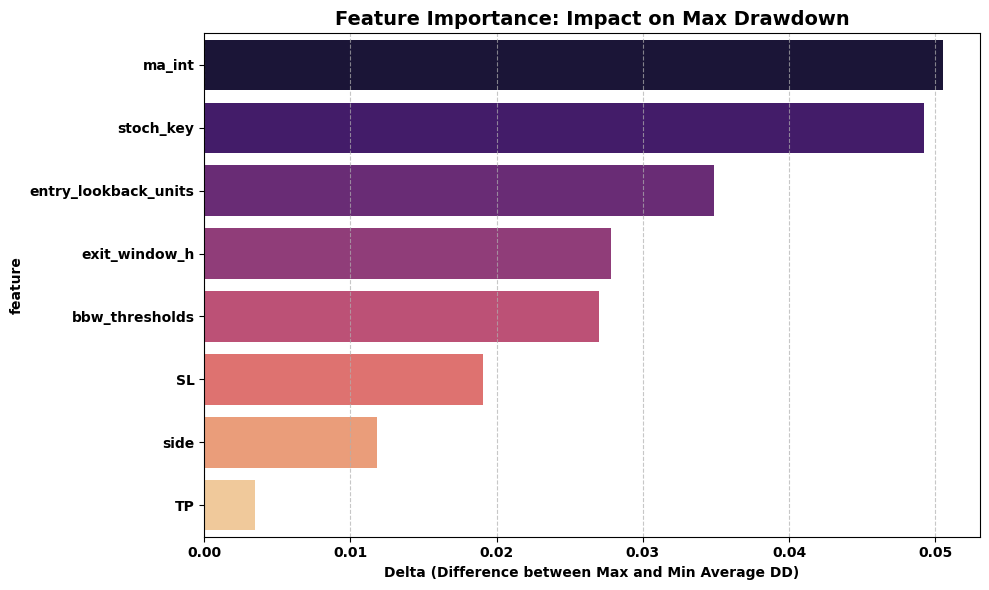


--- FEATURE SENSITIVITY RANKING ---
             feature  dd_delta  min_avg_dd  max_avg_dd
              ma_int  0.050535    0.084331    0.134866
           stoch_key  0.049202    0.072267    0.121469
entry_lookback_units  0.034848    0.080343    0.115190
       exit_window_h  0.027857    0.083451    0.111308
      bbw_thresholds  0.026980    0.087028    0.114008
                  SL  0.019056    0.090808    0.109864
                side  0.011827    0.093309    0.105136
                  TP  0.003467    0.097988    0.101455


In [3]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_feature_importance_dd(df: pl.DataFrame, min_trades_per_era=80):
    """
    Ranks features by how much they influence Max Drawdown.
    Only considers settings with at least min_trades_per_era.
    """
    
    features = [
        "side", "ma_int", "ma_reversion", "entry_lookback_units", 
        "exit_window_h", "stoch_key", "bbw_thresholds", "SL", "TP"
    ]
    
    importance_results = []
    print("Calculating Sensitivity Per Feature...")
    
    for feature in features:
        # Group by feature and calculate average DD + total trades
        stats = (
            df.group_by(feature)
              .agg([
                  pl.col("max_drawdown").mean().alias("mean_dd"),
                  pl.col("total_pos").sum().alias("total_trades")
              ])
              .filter(pl.col("total_trades") >= min_trades_per_era)
        )
        
        if stats.height > 1:
            max_dd = stats["mean_dd"].max()
            min_dd = stats["mean_dd"].min()
            delta = max_dd - min_dd
            
            importance_results.append({
                "feature": feature,
                "dd_delta": delta,
                "min_avg_dd": min_dd,
                "max_avg_dd": max_dd
            })

    importance_df = pl.DataFrame(importance_results).sort("dd_delta", descending=True)
    
    # Visualization
    plt.figure(figsize=(10, 6))
    plot_data = importance_df.to_pandas()
    sns.barplot(data=plot_data, x="dd_delta", y="feature", palette="magma")
    
    plt.title("Feature Importance: Impact on Max Drawdown", fontsize=14)
    plt.xlabel("Delta (Difference between Max and Min Average DD)")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print("\n--- FEATURE SENSITIVITY RANKING ---")
    print(importance_df.to_pandas().to_string(index=False))

# Load relevant columns
cols_to_load = [
    "side", "ma_int", "ma_reversion", "entry_lookback_units", 
    "exit_window_h", "stoch_key", "bbw_thresholds", "SL", "TP", 
    "max_drawdown", "total_pos"
]

df_master = pl.read_parquet(results_path, columns=cols_to_load)
analyze_feature_importance_dd(df_master, min_trades_per_era=80)

In [ ]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_volatility_sensitivity(results_df: pl.DataFrame):
    """
    Correlates Feature Sensitivity (Delta) with hardcoded Volatility Pct from our logs.
    """
    # 1. Hardcoded Volatility Data from your logs
    vol_map = {
        20230901: 61.697750,
        20240301: 154.724207,
        20240901: 49.231199,
        20250301: 106.653570
    }

    features = ["ma_int", "entry_lookback_units", "exit_window_h", "SL", "TP"]
    sensitivity_data = []

    print("Analyzing sensitivity per era...")
    
    # 2. Iterate through eras present in the Parquet file
    available_eras = [e for e in results_df["era_int"].unique() if e in vol_map]
    
    for era in available_eras:
        era_vol = vol_map[era]
        
        for feat in features:
            # Group by feature and find mean DD for this specific era
            stats = (
                results_df.filter(pl.col("era_int") == era)
                .group_by(feat) # Note: Polars newer versions use group_by, not group_by
                .agg(pl.col("max_drawdown").mean().alias("mean_dd"))
                .drop_nulls()
            )
            
            if stats.height > 1:
                delta = stats["mean_dd"].max() - stats["mean_dd"].min()
                sensitivity_data.append({
                    "era_int": era,
                    "volatility_pct": era_vol,
                    "feature": feat,
                    "dd_delta": delta
                })

    if not sensitivity_data:
        print("No overlapping data found between vol_map and Parquet eras.")
        return

    sensitivity_df = pd.DataFrame(sensitivity_data)

    for feat in sensitivity_df["feature"].unique():
        sub = sensitivity_df[sensitivity_df["feature"] == feat]
        if len(sub) >= 3:
            rho = sub["volatility_pct"].corr(sub["dd_delta"], method="spearman")
            print(f"{feat}: spearman rho = {rho:.3f}")
    
    # 3. Pivot to see how Delta changes as volatility moves
    # We sort by volatility_pct so the line chart makes sense chronologically/logically
    pivot_df = sensitivity_df.pivot(index="volatility_pct", columns="feature", values="dd_delta").sort_index()

    corr = pivot_df.corr(method="spearman")
    print("\n--- SPEARMAN CORRELATION (Volatility vs Sensitivity) ---")
    print(corr)
    
    print("\n--- FEATURE SENSITIVITY VS VOLATILITY ---")
    print(pivot_df)
    
    # 4. Plotting
    pivot_df.plot(kind='line', marker='o', figsize=(12, 7), linewidth=2)
    plt.title("Feature Risk Sensitivity vs. Market Volatility", fontsize=14)
    plt.ylabel("DD Delta (Risk Impact)", fontsize=12)
    plt.xlabel("Market Volatility % (6-Month Window)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Strategy Knobs", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

cols_to_load = [
    "era_int", "side", "ma_int", "ma_reversion", "entry_lookback_units", 
    "exit_window_h", "stoch_key", "bbw_thresholds", "SL", "TP", "max_drawdown"
]

# Re-load the data with the required column
df_master = pl.read_parquet(results_path, columns=cols_to_load)
analyze_volatility_sensitivity(df_master)

Analyzing sensitivity per era...


AttributeError: 'DataFrame' object has no attribute 'groupby'

In [9]:
import polars as pl

# Assuming df_master already loaded with needed columns
# Filter meaningful samples
df_filtered = df_master.filter(
    (pl.col("total_pos") > 80) & (pl.col("total_pos") < 1000)
)

# Aggregate mean max_drawdown and balance per era, TP, SL
agg = (
    df_filtered.group_by(["era_int", "TP", "SL"])
    .agg([
        pl.col("max_drawdown").mean().alias("avg_max_drawdown"),
        pl.col("balance").mean().alias("avg_balance"),
        pl.count("total_pos").alias("count_pos")
    ])
)

# For each era, pick the row with lowest avg_max_drawdown
best_per_era = (
    agg.sort(["era_int", "avg_max_drawdown"])
       .group_by("era_int")
       .first()  # first row per era after sorting is lowest drawdown
)

# Optional: sort eras ascending
best_per_era = best_per_era.sort("era_int")

print(best_per_era)

shape: (4, 6)
┌──────────┬─────┬─────┬──────────────────┬─────────────┬───────────┐
│ era_int  ┆ TP  ┆ SL  ┆ avg_max_drawdown ┆ avg_balance ┆ count_pos │
│ ---      ┆ --- ┆ --- ┆ ---              ┆ ---         ┆ ---       │
│ i64      ┆ f32 ┆ f32 ┆ f32              ┆ f32         ┆ u32       │
╞══════════╪═════╪═════╪══════════════════╪═════════════╪═══════════╡
│ 20230901 ┆ 2.5 ┆ 0.3 ┆ 0.110925         ┆ 187.165405  ┆ 14282     │
│ 20240301 ┆ 2.0 ┆ 0.3 ┆ 0.100674         ┆ 138.058929  ┆ 14072     │
│ 20240901 ┆ 3.0 ┆ 0.3 ┆ 0.106115         ┆ 378.968994  ┆ 14342     │
│ 20250301 ┆ 1.5 ┆ 0.3 ┆ 0.095878         ┆ 128.341232  ┆ 16544     │
└──────────┴─────┴─────┴──────────────────┴─────────────┴───────────┘


In [ ]:
import polars as pl

def get_high_quality_tp_candidates(df: pl.DataFrame, top_n_percent=0.10):
    """
    Identifies TPs that consistently rank in the top percentile 
    using Window Functions (compatible with older Polars).
    """
    
    # 1. Calculate Efficiency Ratio
    df_scored = df.with_columns([
        ((pl.col("balance") - 100) / (pl.col("max_drawdown") + 0.001)).alias("efficiency_ratio")
    ])

    # 2. Filter for Top N% using a Window Function (.over)
    # This replaces the broken .map_groups() or .apply() logic
    top_candidates = df_scored.filter(
        pl.col("efficiency_ratio") >= 
        pl.col("efficiency_ratio").quantile(1 - top_n_percent).over("era_int")
    )

    # 3. Count appearances across eras using group_by
    tp_ranking = (
        top_candidates
        .group_by("TP")
        .agg([
            pl.count("era_int").alias("appearance_count"),
            pl.col("max_drawdown").mean().alias("avg_dd_when_elite"),
            pl.col("balance").mean().alias("avg_bal_when_elite")
        ])
        .sort("appearance_count", descending=True)
    )

    print(f"--- HIGH-PROBABILITY TP CANDIDATES (Top {top_n_percent*100}%) ---")
    print(tp_ranking.head(10))
    
    # Extract the best candidates
    recommended_tps = tp_ranking.filter(pl.col("appearance_count") > 1)["TP"].to_list()
    print(f"\nSuggested TP list for next run: {recommended_tps}")
    
    return recommended_tps

# EXECUTION
top_tps = get_high_quality_tp_candidates(df_master)

--- HIGH-PROBABILITY TP CANDIDATES (Top 10.0%) ---
shape: (10, 4)
┌─────┬──────────────────┬───────────────────┬────────────────────┐
│ TP  ┆ appearance_count ┆ avg_dd_when_elite ┆ avg_bal_when_elite │
│ --- ┆ ---              ┆ ---               ┆ ---                │
│ f32 ┆ u32              ┆ f32               ┆ f32                │
╞═════╪══════════════════╪═══════════════════╪════════════════════╡
│ 2.0 ┆ 19002            ┆ 0.028484          ┆ 113.447533         │
│ 2.2 ┆ 17964            ┆ 0.030172          ┆ 114.968987         │
│ 2.4 ┆ 17146            ┆ 0.031893          ┆ 116.408333         │
│ 1.8 ┆ 16875            ┆ 0.029623          ┆ 114.154587         │
│ 1.6 ┆ 16288            ┆ 0.028706          ┆ 113.532036         │
│ 1.4 ┆ 11834            ┆ 0.030185          ┆ 114.521034         │
│ 1.2 ┆ 10971            ┆ 0.029132          ┆ 113.626808         │
│ 1.0 ┆ 6906             ┆ 0.032483          ┆ 114.53421          │
│ 0.8 ┆ 6312             ┆ 0.02937           ┆ 113

In [ ]:
import polars as pl

def analyze_sl_pairing(df: pl.DataFrame, target_tp=2.0):
    """
    Zooms into a specific TP to find the most efficient SL pairings.
    """
    # 1. Filter for the target TP and meaningful trade counts
    df_zoom = df.filter(
        (pl.col("TP") == target_tp) & 
        (pl.col("total_pos") > 50)
    )

    # 2. Calculate Efficiency per SL across all eras
    sl_stats = (
        df_zoom.group_by("SL")
        .agg([
            pl.count("era_int").alias("config_count"),
            pl.col("balance").mean().alias("avg_balance"),
            pl.col("max_drawdown").mean().alias("avg_dd"),
            # Recovery Factor: (Net Profit) / Drawdown
            ((pl.col("balance").mean() - 100) / (pl.col("max_drawdown").mean() + 0.001)).alias("recovery_factor")
        ])
        .sort("recovery_factor", descending=True)
    )

    print(f"--- SL PAIRING ANALYSIS FOR TP {target_tp} ---")
    print(sl_stats)
    
    best_sl = sl_stats["SL"]
    print(f"\nWinner: The most efficient SL for TP {target_tp} is {best_sl}")
    
    return sl_stats

# EXECUTION
sl_results = analyze_sl_pairing(df_master, target_tp=2.0)

--- SL PAIRING ANALYSIS FOR TP 2.0 ---
shape: (5, 5)
┌─────┬──────────────┬─────────────┬──────────┬─────────────────┐
│ SL  ┆ config_count ┆ avg_balance ┆ avg_dd   ┆ recovery_factor │
│ --- ┆ ---          ┆ ---         ┆ ---      ┆ ---             │
│ f32 ┆ u32          ┆ f32         ┆ f32      ┆ f64             │
╞═════╪══════════════╪═════════════╪══════════╪═════════════════╡
│ 0.1 ┆ 5336         ┆ 108.528145  ┆ 0.130347 ┆ 64.928187       │
│ 0.2 ┆ 5333         ┆ 105.7631    ┆ 0.11587  ┆ 49.311889       │
│ 0.3 ┆ 5332         ┆ 102.530128  ┆ 0.110043 ┆ 22.7852         │
│ 0.4 ┆ 5332         ┆ 100.275589  ┆ 0.104676 ┆ 2.607858        │
│ 0.5 ┆ 5328         ┆ 99.083801   ┆ 0.101598 ┆ -8.93           │
└─────┴──────────────┴─────────────┴──────────┴─────────────────┘

Winner: The most efficient SL for TP 2.0 is shape: (5,)
Series: 'SL' [f32]
[
	0.1
	0.2
	0.3
	0.4
	0.5
]


In [ ]:
import polars as pl

MIN_TRADES = 70 
MAX_TRADES = 120 # Added some padding for high-volatility months

needed_cols = ["stoch_key", "ma_int", "era_int", "entry_lookback_units", "max_drawdown", "balance", "total_pos", "win_pos","SL", "TP"]
df_master = pl.read_parquet(results_path, columns=needed_cols)


def analyze_sl_pairing_detailed(df: pl.DataFrame, target_tp=2.0):
    """
    Zooms into SL pairings with Win Rate and Position Count.
    """
    # 1. Filter for the target TP
    df_zoom = df.filter(pl.col("TP") == target_tp)

    # 2. Aggregate with Win Rate and Position Count
    sl_stats = (
        df_zoom.group_by("SL")
        .agg([
            pl.count("era_int").alias("config_count"),
            pl.col("total_pos").mean().alias("avg_pos_count"),
            # Win Rate calculation
            (pl.col("win_pos").sum() / pl.col("total_pos").sum()).alias("avg_win_rate"),
            pl.col("balance").mean().alias("avg_balance"),
            pl.col("max_drawdown").mean().alias("avg_dd"),
            # Recovery Factor
            ((pl.col("balance").mean() - 100) / (pl.col("max_drawdown").mean() + 0.001)).alias("recovery_factor")
        ])
        .sort("recovery_factor", descending=True)
    )

    print(f"--- DETAILED SL ANALYSIS FOR TP {target_tp} ---")
    print(sl_stats)
    return sl_stats

# EXECUTION
sl_detailed = analyze_sl_pairing_detailed(df_master, target_tp=2.0)

--- DETAILED SL ANALYSIS FOR TP 2.0 ---
shape: (5, 7)
┌─────┬──────────────┬───────────────┬──────────────┬─────────────┬──────────┬─────────────────┐
│ SL  ┆ config_count ┆ avg_pos_count ┆ avg_win_rate ┆ avg_balance ┆ avg_dd   ┆ recovery_factor │
│ --- ┆ ---          ┆ ---           ┆ ---          ┆ ---         ┆ ---      ┆ ---             │
│ f32 ┆ u32          ┆ f64           ┆ f64          ┆ f32         ┆ f32      ┆ f64             │
╞═════╪══════════════╪═══════════════╪══════════════╪═════════════╪══════════╪═════════════════╡
│ 0.2 ┆ 36476        ┆ 24.083918     ┆ 0.10671      ┆ 101.539276  ┆ 0.034282 ┆ 43.627852       │
│ 0.1 ┆ 36488        ┆ 24.082109     ┆ 0.053719     ┆ 101.193138  ┆ 0.039491 ┆ 29.466857       │
│ 0.3 ┆ 36468        ┆ 24.08635      ┆ 0.141411     ┆ 100.900635  ┆ 0.032238 ┆ 27.096796       │
│ 0.4 ┆ 36462        ┆ 24.086309     ┆ 0.168743     ┆ 100.351418  ┆ 0.03047  ┆ 11.166693       │
│ 0.5 ┆ 36454        ┆ 24.083475     ┆ 0.190338     ┆ 99.896843   ┆ 0.029

In [ ]:
import polars as pl

# 1. Calculate your frequency target
# 26 weeks * (3 to 4 trades) = 78 to 104
MIN_TRADES = 70 
MAX_TRADES = 120 # Added some padding for high-volatility months

# 2. Apply the frequency filter to your master data
df_active = df_master.filter(
    (pl.col("total_pos") >= MIN_TRADES) & 
    (pl.col("total_pos") <= MAX_TRADES)
)

def analyze_active_sl_pairing(df: pl.DataFrame, target_tp=2.0):
    """
    Analyzes SL pairings specifically for active strategies (3-4 trades/week).
    """
    sl_stats = (
        df.filter(pl.col("TP") == target_tp)
        .group_by("SL")
        .agg([
            pl.count("era_int").alias("config_count"),
            pl.col("total_pos").mean().alias("avg_pos_count"),
            (pl.col("win_pos").sum() / pl.col("total_pos").sum()).alias("win_rate"),
            pl.col("balance").mean().alias("avg_balance"),
            pl.col("max_drawdown").mean().alias("avg_dd"),
            ((pl.col("balance").mean() - 100) / (pl.col("max_drawdown").mean() + 0.001)).alias("recovery_factor")
        ])
        .sort("recovery_factor", descending=True)
    )

    print(f"--- ACTIVE STRATEGY ANALYSIS (70-120 Trades/Era) | TP {target_tp} ---")
    print(sl_stats)
    return sl_stats

# EXECUTION
active_sl_results = analyze_active_sl_pairing(df_active, target_tp=2.0)

--- ACTIVE STRATEGY ANALYSIS (70-120 Trades/Era) | TP 2.0 ---
shape: (5, 7)
┌─────┬──────────────┬───────────────┬──────────┬─────────────┬──────────┬─────────────────┐
│ SL  ┆ config_count ┆ avg_pos_count ┆ win_rate ┆ avg_balance ┆ avg_dd   ┆ recovery_factor │
│ --- ┆ ---          ┆ ---           ┆ ---      ┆ ---         ┆ ---      ┆ ---             │
│ f32 ┆ u32          ┆ f64           ┆ f64      ┆ f32         ┆ f32      ┆ f64             │
╞═════╪══════════════╪═══════════════╪══════════╪═════════════╪══════════╪═════════════════╡
│ 0.1 ┆ 2141         ┆ 88.49603      ┆ 0.056494 ┆ 106.062836  ┆ 0.132295 ┆ 45.484416       │
│ 0.2 ┆ 2141         ┆ 88.49603      ┆ 0.103853 ┆ 104.429329  ┆ 0.117754 ┆ 37.298218       │
│ 0.3 ┆ 2141         ┆ 88.49603      ┆ 0.135615 ┆ 101.641289  ┆ 0.111623 ┆ 14.573334       │
│ 0.4 ┆ 2141         ┆ 88.49603      ┆ 0.161413 ┆ 99.671913   ┆ 0.104798 ┆ -3.101054       │
│ 0.5 ┆ 2140         ┆ 88.501402     ┆ 0.186337 ┆ 98.587196   ┆ 0.101629 ┆ -13.76616   

In [ ]:
import polars as pl

vol_data = [
    {"era_int": 20230901, "volatility_pct": 61.697750, "volatility_index": 0.616978},
    {"era_int": 20240301, "volatility_pct": 154.724207, "volatility_index": 1.547242},
    {"era_int": 20240901, "volatility_pct": 49.231199, "volatility_index": 0.492312},
    {"era_int": 20250301, "volatility_pct": 106.653570, "volatility_index": 1.066536},
]

df_volatility = pl.DataFrame(vol_data)

# df_master: your master grid search results (columns include era_int, TP)
# df_volatility: era-level volatility table (columns: era_int, volatility_pct)

# 1️⃣ Aggregate TP, SL, and DD per era from your master results
df_era_tp = (
    df_master
    .group_by("era_int") # .group_by is the modern Polars syntax
    .agg([
        pl.col("TP").mean().alias("avg_TP"),
        pl.col("SL").mean().alias("avg_SL"),
        pl.col("max_drawdown").mean().alias("avg_dd")
    ])
)

# 2️⃣ Join with the hardcoded era volatility
df_era_full = df_era_tp.join(
    df_volatility.select(["era_int", "volatility_pct"]), 
    on="era_int"
)

# 3️⃣ Compute Spearman correlation (Pearson on Ranks)

df_ranks = df_era_full.select([
    pl.col("avg_TP").rank().alias("TP_rank"),
    pl.col("volatility_pct").rank().alias("vol_rank")
])

# Use pl.corr() as a top-level function
spearman_rho = df_ranks.select(
    pl.corr("TP_rank", "vol_rank")
).item() # .item() is cleaner than .to_numpy() for single values

print(f"--- VOLATILITY VS PERFORMANCE CORRELATION ---")
print(f"Spearman rho (Avg TP vs Volatility) = {spearman_rho:.3f}")

# Optional: Print the summary table to see the raw alignment
print("\nEra Alignment Summary:")
print(df_era_full.sort("volatility_pct"))

print(f"Spearman rho (TP vs volatility) = {spearman_rho:.3f}")

--- VOLATILITY VS PERFORMANCE CORRELATION ---
Spearman rho (Avg TP vs Volatility) = -0.600

Era Alignment Summary:
shape: (4, 5)
┌──────────┬──────────┬──────────┬──────────┬────────────────┐
│ era_int  ┆ avg_TP   ┆ avg_SL   ┆ avg_dd   ┆ volatility_pct │
│ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---            │
│ i64      ┆ f32      ┆ f32      ┆ f32      ┆ f64            │
╞══════════╪══════════╪══════════╪══════════╪════════════════╡
│ 20240901 ┆ 1.685511 ┆ 0.242817 ┆ 0.028347 ┆ 49.231199      │
│ 20230901 ┆ 1.685531 ┆ 0.242813 ┆ 0.026294 ┆ 61.69775       │
│ 20250301 ┆ 1.685491 ┆ 0.242819 ┆ 0.041319 ┆ 106.65357      │
│ 20240301 ┆ 1.685492 ┆ 0.242822 ┆ 0.027868 ┆ 154.724207     │
└──────────┴──────────┴──────────┴──────────┴────────────────┘
Spearman rho (TP vs volatility) = -0.600


In [ ]:
import polars as pl

# 1. Define your "Optimal" constraints
target_tp = 2.0
target_sls = [0.1, 0.2]
target_stoch = "k6_d6_s6_l30_u70"
target_ma = 7
target_lookbacks = [6, 8]

# 2. Apply the surgical filter
df_optimal = df_master.filter(
    (pl.col("TP") == target_tp) &
    (pl.col("SL").is_in(target_sls)) &
    (pl.col("stoch_key") == target_stoch) &
    (pl.col("ma_int") == target_ma) &
    (pl.col("entry_lookback_units").is_in(target_lookbacks))
)

# 3. Aggregate results per Era to see if this "Dream Config" survives all market types
optimal_summary = (
    df_optimal.group_by(["era_int", "SL", "entry_lookback_units"])
    .agg([
        pl.col("total_pos").mean().alias("trades"),
        (pl.col("win_pos").sum() / pl.col("total_pos").sum()).alias("win_rate"),
        pl.col("balance").mean().alias("avg_bal"),
        pl.col("max_drawdown").mean().alias("avg_dd"),
        ((pl.col("balance").mean() - 100) / (pl.col("max_drawdown").mean() + 0.001)).alias("rec_factor")
    ])
    .sort(["era_int", "rec_factor"], descending=[False, True])
)

print(f"--- PERFORMANCE OF OPTIMAL CONFIGS ACROSS ERAS ---")
print(optimal_summary)

# 4. Final Verification: Check if any config is a "Universal Winner" (present in all eras)
consistency = (
    optimal_summary.group_by(["SL", "entry_lookback_units"])
    .agg(pl.count("era_int").alias("eras_active"))
    .sort("eras_active", descending=True)
)

print("\n--- CONSISTENCY CHECK (Are these settings active in all 4 Eras?) ---")
print(consistency)

--- PERFORMANCE OF OPTIMAL CONFIGS ACROSS ERAS ---
shape: (16, 8)
┌──────────┬─────┬──────────────────────┬───────────┬──────────┬────────────┬──────────┬────────────┐
│ era_int  ┆ SL  ┆ entry_lookback_units ┆ trades    ┆ win_rate ┆ avg_bal    ┆ avg_dd   ┆ rec_factor │
│ ---      ┆ --- ┆ ---                  ┆ ---       ┆ ---      ┆ ---        ┆ ---      ┆ ---        │
│ i64      ┆ f32 ┆ i32                  ┆ f64       ┆ f64      ┆ f32        ┆ f32      ┆ f64        │
╞══════════╪═════╪══════════════════════╪═══════════╪══════════╪════════════╪══════════╪════════════╡
│ 20230901 ┆ 0.2 ┆ 8                    ┆ 45.0      ┆ 0.099074 ┆ 101.355904 ┆ 0.063108 ┆ 21.150239  │
│ 20230901 ┆ 0.2 ┆ 6                    ┆ 78.5      ┆ 0.086518 ┆ 98.9804    ┆ 0.10836  ┆ -9.323366  │
│ 20230901 ┆ 0.1 ┆ 6                    ┆ 78.5      ┆ 0.019639 ┆ 87.027565  ┆ 0.143834 ┆ -89.567417 │
│ 20230901 ┆ 0.1 ┆ 8                    ┆ 45.0      ┆ 0.012037 ┆ 90.34623   ┆ 0.100006 ┆ -95.576101 │
│ 20240301 ┆ 0.1

In [ ]:
import polars as pl


# Update this list to include the BBW columns
needed_cols = [
    "stoch_key", "ma_int", "era_int", "entry_lookback_units", 
    "max_drawdown", "balance", "total_pos", "win_pos", "SL", "TP",
    "use_bbw", "bbw_periods"  # <--- Added these
]

# Re-load the master dataframe
df_master = pl.read_parquet(results_path, columns=needed_cols)

# 1. Reuse your 'Optimal' core settings
target_tp = 2.0
target_sls = [0.1, 0.2]
target_stoch = "k6_d6_s6_l30_u70"
target_ma = 7
target_lookbacks = [6, 8]

# 2. Filter base data
df_optimal_base = df_master.filter(
    (pl.col("TP") == target_tp) &
    (pl.col("SL").is_in(target_sls)) &
    (pl.col("stoch_key") == target_stoch) &
    (pl.col("ma_int") == target_ma) &
    (pl.col("entry_lookback_units").is_in(target_lookbacks))
)

# 3. Analyze BBW Filter Impact
bbw_analysis = (
    df_optimal_base.group_by(["use_bbw", "bbw_periods"])
    .agg([
        pl.count("era_int").alias("config_count"),
        pl.col("total_pos").mean().alias("avg_trades"),
        (pl.col("win_pos").sum() / pl.col("total_pos").sum()).alias("win_rate"),
        pl.col("balance").mean().alias("avg_bal"),
        pl.col("max_drawdown").mean().alias("avg_dd"),
        # Recovery Factor calculation
        ((pl.col("balance").mean() - 100) / (pl.col("max_drawdown").mean() + 0.001)).alias("rec_factor")
    ])
    .sort("rec_factor", descending=True)
)

print("--- BBW FILTER IMPACT ANALYSIS ---")
print(bbw_analysis)

# 4. Check if BBW saved the 'Bad Era' (2023-09-01)
print("\n--- BBW PERFORMANCE IN 2023-09 (DRAWDOWM CHECK) ---")
print(
    df_optimal_base.filter(pl.col("era_int") == 20230901)
    .group_by(["use_bbw", "bbw_periods"])
    .agg([
        pl.col("total_pos").mean().alias("trades"),
        pl.col("max_drawdown").mean().alias("avg_dd"),
        pl.col("balance").mean().alias("avg_bal")
    ])
    .sort("avg_dd")
)

--- BBW FILTER IMPACT ANALYSIS ---
shape: (3, 8)
┌─────────┬─────────────┬──────────────┬────────────┬──────────┬────────────┬──────────┬────────────┐
│ use_bbw ┆ bbw_periods ┆ config_count ┆ avg_trades ┆ win_rate ┆ avg_bal    ┆ avg_dd   ┆ rec_factor │
│ ---     ┆ ---         ┆ ---          ┆ ---        ┆ ---      ┆ ---        ┆ ---      ┆ ---        │
│ bool    ┆ i32         ┆ u32          ┆ f64        ┆ f64      ┆ f32        ┆ f32      ┆ f64        │
╞═════════╪═════════════╪══════════════╪════════════╪══════════╪════════════╪══════════╪════════════╡
│ true    ┆ 96          ┆ 128          ┆ 53.75      ┆ 0.113663 ┆ 111.959793 ┆ 0.080554 ┆ 146.648086 │
│ false   ┆ 0           ┆ 128          ┆ 92.5625    ┆ 0.097485 ┆ 114.842171 ┆ 0.104358 ┆ 140.873778 │
│ true    ┆ 48          ┆ 128          ┆ 69.5       ┆ 0.089703 ┆ 106.872719 ┆ 0.094872 ┆ 71.686442  │
└─────────┴─────────────┴──────────────┴────────────┴──────────┴────────────┴──────────┴────────────┘

--- BBW PERFORMANCE IN 2023-09 (

In [ ]:
import polars as pl

# 1. Load the data with all necessary columns
needed_cols = [
    "era_int", "total_pos", "win_pos", "balance", 
    "max_drawdown", "use_bbw", "bbw_periods"
]
df_full = pl.read_parquet(results_path, columns=needed_cols)

# 2. Compare the "Raw" performance of BBW 96 vs No BBW
# We fill nulls for the 'False' group to allow for clean grouping
raw_era_analysis = (
    df_full.filter(
        (pl.col("use_bbw") == False) | (pl.col("bbw_periods") == 96)
    )
    .with_columns(pl.col("bbw_periods").fill_null(0))
    .group_by(["era_int", "use_bbw"])
    .agg([
        pl.count("balance").alias("config_variants"), # How many settings exist here
        pl.col("total_pos").mean().alias("avg_trades"),
        (pl.col("win_pos").sum() / pl.col("total_pos").sum()).alias("global_win_rate"),
        pl.col("balance").mean().alias("avg_bal"),
        pl.col("max_drawdown").mean().alias("avg_dd"),
        # Calculation for global efficiency across all 1.2M rows
        ((pl.col("balance").mean() - 100) / (pl.col("max_drawdown").mean() + 0.001)).alias("rec_factor")
    ])
    .sort(["era_int", "use_bbw"])
)

print("--- RAW GLOBAL IMPACT: BBW 96 vs NO FILTER (ALL CONFIGS) ---")
print(raw_era_analysis)

--- RAW GLOBAL IMPACT: BBW 96 vs NO FILTER (ALL CONFIGS) ---
shape: (10, 8)
┌──────────┬─────────┬─────────────────┬────────────┬─────────────────┬────────────┬──────────┬────────────┐
│ era_int  ┆ use_bbw ┆ config_variants ┆ avg_trades ┆ global_win_rate ┆ avg_bal    ┆ avg_dd   ┆ rec_factor │
│ ---      ┆ ---     ┆ ---             ┆ ---        ┆ ---             ┆ ---        ┆ ---      ┆ ---        │
│ i64      ┆ bool    ┆ u32             ┆ f64        ┆ f64             ┆ f32        ┆ f32      ┆ f64        │
╞══════════╪═════════╪═════════════════╪════════════╪═════════════════╪════════════╪══════════╪════════════╡
│ 20230901 ┆ false   ┆ 106400          ┆ 27.002961  ┆ 0.139792        ┆ 100.854652 ┆ 0.031518 ┆ 26.282757  │
│ 20230901 ┆ true    ┆ 105990          ┆ 13.994575  ┆ 0.15212         ┆ 100.885849 ┆ 0.021109 ┆ 40.066936  │
│ 20240301 ┆ false   ┆ 106280          ┆ 28.07532   ┆ 0.130072        ┆ 100.343513 ┆ 0.033375 ┆ 9.993154   │
│ 20240301 ┆ true    ┆ 105850          ┆ 14.098536  

In [ ]:
import polars as pl

# 1. Update needed columns for the new analysis
needed_cols = ["stoch_key", "ma_int", "era_int", "balance", "max_drawdown", "total_pos", "use_bbw", "bbw_periods"]
df_master = pl.read_parquet(results_path, columns=needed_cols)

def analyze_stoch_stability(df: pl.DataFrame):
    """
    Analyzes Stochastic keys across eras, filtered by the BBW 96 'Shield'.
    """
    # Filter for our 'Golden' structural base
    df_shielded = df.filter(
        (pl.col("ma_int") == 7) & 
        (pl.col("use_bbw") == True) & 
        (pl.col("bbw_periods") == 96)
    )

    # 1. Aggregate performance per Era and Stoch Key
    stoch_era_stats = (
        df_shielded.group_by(["stoch_key", "era_int"])
        .agg([
            pl.col("balance").mean().alias("avg_bal"),
            pl.col("max_drawdown").mean().alias("avg_dd"),
            pl.col("total_pos").mean().alias("avg_trades")
        ])
    )

    # 2. Final Ranking: Calculate consistency across all Eras
    stoch_ranking = (
        stoch_era_stats.group_by("stoch_key")
        .agg([
            pl.count("era_int").alias("eras_active"),
            # Count how many eras the average balance was > 100
            (pl.col("avg_bal") > 100).sum().alias("profitable_eras"),
            pl.col("avg_bal").mean().alias("global_avg_bal"),
            pl.col("avg_dd").mean().alias("global_avg_dd"),
            pl.col("avg_trades").sum().alias("total_trades_2yr")
        ])
        .with_columns([
            ((pl.col("global_avg_bal") - 100) / (pl.col("global_avg_dd") + 0.001)).alias("stability_recovery")
        ])
        .sort(["profitable_eras", "stability_recovery"], descending=True)
    )

    print(f"\n" + "="*95)
    print(f" STOCHASTIC STABILITY RANKING (BBW 96 + MA 7) ")
    print("="*95)
    print(stoch_ranking.head(15))

# --- EXECUTION ---
analyze_stoch_stability(df_master)


 STOCHASTIC STABILITY RANKING (BBW 96 + MA 7) 
shape: (8, 7)
┌────────────────────┬─────────────┬─────────────────┬────────────────┬───────────────┬──────────────────┬────────────────────┐
│ stoch_key          ┆ eras_active ┆ profitable_eras ┆ global_avg_bal ┆ global_avg_dd ┆ total_trades_2yr ┆ stability_recovery │
│ ---                ┆ ---         ┆ ---             ┆ ---            ┆ ---           ┆ ---              ┆ ---                │
│ str                ┆ u32         ┆ u32             ┆ f32            ┆ f32           ┆ f64              ┆ f64                │
╞════════════════════╪═════════════╪═════════════════╪════════════════╪═══════════════╪══════════════════╪════════════════════╡
│ k6_d6_s6_l30_u70   ┆ 4           ┆ 3               ┆ 106.074402     ┆ 0.056867      ┆ 168.333333       ┆ 104.971849         │
│ k6_d6_s12_l30_u70  ┆ 4           ┆ 3               ┆ 101.781853     ┆ 0.03671       ┆ 88.0             ┆ 47.251035          │
│ k6_d12_s6_l30_u70  ┆ 5           ┆ 3    

In [ ]:
import polars as pl
df_master = pl.read_parquet(results_path)

# 1. Define Target Stoch
target_stoch = "k6_d6_s6_l30_u70"

# 2. Identify the 'Elite' Threshold per Era (Top 10% of ALL configs)
elite_thresholds = (
    df_master.with_columns([
        ((pl.col("balance") - 100) / (pl.col("max_drawdown") + 0.001)).alias("efficiency_ratio")
    ])
    .group_by("era_int")
    .agg(pl.col("efficiency_ratio").quantile(0.90).alias("elite_cutoff"))
)

# 3. Apply the comparison logic
df_stoch_base = df_master.filter(pl.col("stoch_key") == target_stoch).join(elite_thresholds, on="era_int")

# Add Efficiency and Elite Status
df_stoch_base = df_stoch_base.with_columns([
    ((pl.col("balance") - 100) / (pl.col("max_drawdown") + 0.001)).alias("efficiency_ratio")
]).with_columns([
    (pl.col("efficiency_ratio") >= pl.col("elite_cutoff")).alias("is_elite")
])

# 4. Comparative Aggregation
comparison = (
    df_stoch_base.with_columns([
        pl.when(pl.col("ma_int") == 0)
          .then(pl.lit("Stoch Only"))
        .when(pl.col("ma_int") == 7)
          .then(pl.lit("Stoch + MA 7"))
        .otherwise(pl.lit("Stoch + Other MA"))
        .alias("Group")
    ])
    .group_by("Group")
    .agg([
        pl.count().alias("rows"),
        pl.col("balance").mean().alias("avg_bal"),
        pl.col("total_pos").mean().alias("avg_trades"),
        pl.col("max_drawdown").mean().alias("avg_dd"),
        pl.col("efficiency_ratio").mean().alias("avg_efficiency"),
        (pl.col("is_elite").sum() / pl.count() * 100).alias("elite_frequency_pct"),
    ])
    .sort("rows", descending=True)
)

print(comparison)

print("--- PERFORMANCE COMPARISON: STOCH ENGINE VS MA 7 SHIELD ---")
print(comparison)

lb_check = (
    df_master.filter((pl.col("stoch_key") == "k6_d6_s6_l30_u70") & (pl.col("ma_int") == 7))
    .group_by("entry_lookback_units")
    .agg(pl.col("total_pos").mean().alias("avg_trades"))
)
print(lb_check)

shape: (3, 7)
┌──────────────────┬────────┬────────────┬────────────┬──────────┬────────────────┬─────────────────────┐
│ Group            ┆ rows   ┆ avg_bal    ┆ avg_trades ┆ avg_dd   ┆ avg_efficiency ┆ elite_frequency_pct │
│ ---              ┆ ---    ┆ ---        ┆ ---        ┆ ---      ┆ ---            ┆ ---                 │
│ str              ┆ u32    ┆ f32        ┆ f64        ┆ f32      ┆ f64            ┆ i32                 │
╞══════════════════╪════════╪════════════╪════════════╪══════════╪════════════════╪═════════════════════╡
│ Stoch + Other MA ┆ 140200 ┆ 105.154556 ┆ 62.626391  ┆ 0.069666 ┆ 134.997156     ┆ 0                   │
│ Stoch + MA 7     ┆ 10080  ┆ 105.629639 ┆ 55.444444  ┆ 0.064613 ┆ 147.220012     ┆ 0                   │
│ Stoch Only       ┆ 10080  ┆ 111.202179 ┆ 190.125    ┆ 0.118148 ┆ 137.026011     ┆ 0                   │
└──────────────────┴────────┴────────────┴────────────┴──────────┴────────────────┴─────────────────────┘
--- PERFORMANCE COMPARISON: STOC